# Kerala Weather Forecast and Analysis
# Kannur vs Kozhikode | 5-Day Forecast + ML prediction

## Problem statement 
Weather forecasting is critical for daily life in Kerala, a state highly dependent on agricultre and tourism.
However,most people rely on generic national forecasts that doesn't capture city level differences.

** This Project Answers **
- How does weather differ between Kannur and Kozhikode?
- What will temperatures look like beyond the 5-day forecast window?
- Can i identify patterns in humidity and rainfall probability?

## Approach
1. Extract - Fetch live 5-day forecast data from OpenWeatherMap API
2. Transform - Clean and structure data using pandas
3. Load - Stores in SQLite database
4. Analyse - Compares cities through visualisations
5. Predict - Extend forecast using Linear Regression
  

In [17]:
# IMPORTS
import requests
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import sqlite3
import logging
import numpy as np
from sklearn.linear_model import LinearRegression

In [18]:
# Setting up logging to monitor 
logging.basicConfig(level=logging.INFO,format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)

In [20]:
# Securely loading API key from environment variable
API_KEY = os.environ.get("OPENWEATHER_API_KEY","YOUR_API_KEY_HERE")
CITIES = ["Kannur", "Kozhikode"]

def fetch_forecast(city):
    url = f"https://api.openweathermap.org/data/2.5/forecast?q={city},IN&appid={API_KEY}&units=metric"
    try:
        logger.info(f"Fetching forecast for {city}...")
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        logger.info(f"Success for {city}")
        return response.json()
    except requests.RequestException as e:
        logger.error(f"Failed for {city}: {e}")
        return None

# Fetch forecasts for all cities
raw_data = {city: fetch_forecast(city) for city in CITIES}

2026-03-18 22:30:59,185 - INFO - Fetching forecast for Kannur...
2026-03-18 22:31:00,280 - INFO - Success for Kannur
2026-03-18 22:31:00,286 - INFO - Fetching forecast for Kozhikode...
2026-03-18 22:31:01,336 - INFO - Success for Kozhikode


In [21]:
# Converting raw JSON API response into a structured dataframe
# extracting only the fields i need
def transform_forecast(raw, city):
    return pd.DataFrame([{
        "city": city,
        "datetime": item["dt_txt"],
        "temperature": item["main"]["temp"],
        "feels_like": item["main"]["feels_like"],
        "humidity": item["main"]["humidity"],
        "pressure": item["main"]["pressure"],
        "wind_speed": item["wind"]["speed"],
        "weather": item["weather"][0]["main"],
        "description": item["weather"][0]["description"],
    } for item in raw["list"]])
    
# Transforming data from each city and combining into one DataFrame
df_all = pd.concat([
    transform_forecast(raw_data["Kannur"], "Kannur"),
    transform_forecast(raw_data["Kozhikode"], "Kozhikode")
], ignore_index=True)

#Changing to proper date format
df_all["datetime"] = pd.to_datetime(df_all["datetime"])
df_all.head()

,city,datetime,temperature,feels_like,humidity,pressure,wind_speed,weather,description
0,Kannur,2026-03-18 18:00:00,25.75,26.44,79,1012,2.02,Rain,light rain
1,Kannur,2026-03-18 21:00:00,25.02,25.72,82,1012,1.60,Rain,light rain
2,Kannur,2026-03-19 00:00:00,23.97,24.69,87,1011,1.95,Rain,light rain
3,Kannur,2026-03-19 03:00:00,25.40,26.06,79,1014,1.55,Rain,light rain
4,Kannur,2026-03-19 06:00:00,28.94,31.24,62,1014,2.86,Clear,clear sky


In [22]:
# Storing cleaned forecast data into SQLite database
def load_to_db(df, db_path="kerala_weather.db"):
    
    conn = sqlite3.connect(db_path) #Creates db file if it doesn't exist
    
    df.to_sql("forecast", conn, if_exists="replace", index=False) #if exists-drops and recreates table on each run
    count = pd.read_sql("SELECT COUNT(*) as total FROM forecast", conn)
    logger.info(f"Loaded {count['total'][0]} records into database")
    conn.close()

# Saving df
load_to_db(df_all)

2026-03-18 22:31:01,497 - INFO - Loaded 80 records into database


## 1. Temperature comparison: Kannur vs Kozhikode
Analyzing how temperatures differ between the two cities over the 5-day forecast period.

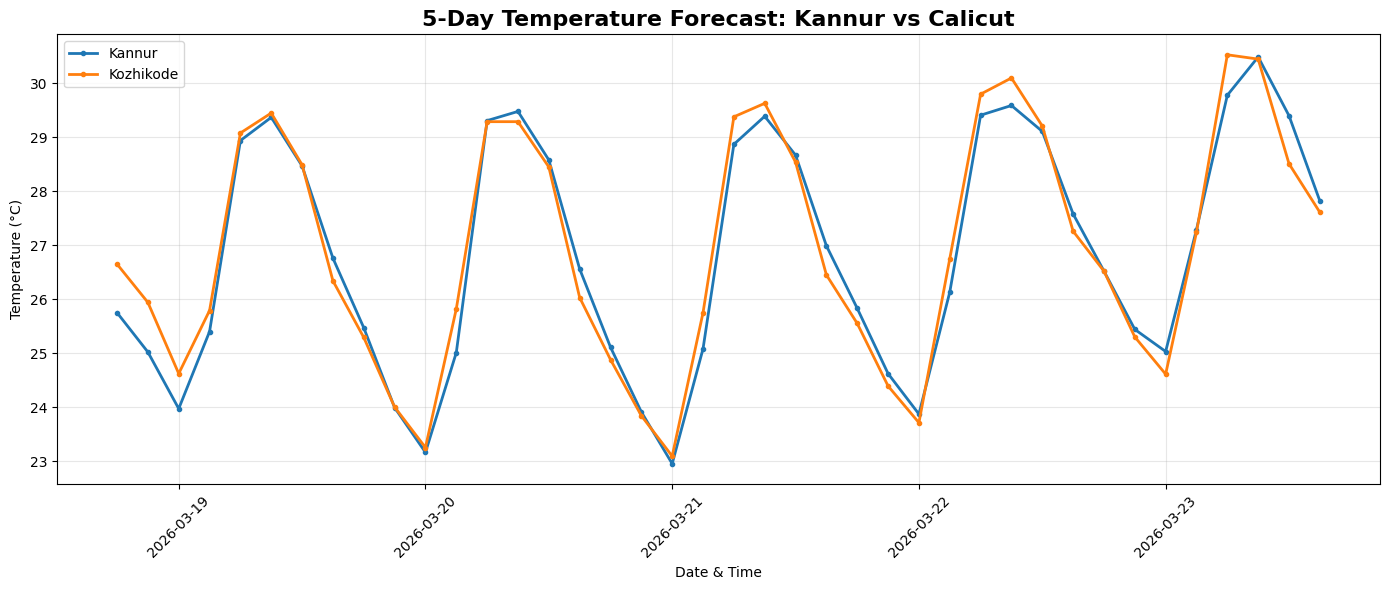

In [23]:
plt.figure(figsize=(14, 6))
for city in CITIES:
    city_name = "Kozhikode" if city == "Kozhikode" else city
    df_city = df_all[df_all["city"] == city_name]
    plt.plot(df_city["datetime"], df_city["temperature"],
             marker="o", markersize=3, label=city_name, linewidth=2)

plt.title("5-Day Temperature Forecast: Kannur vs Calicut", fontsize=16, fontweight="bold")
plt.xlabel("Date & Time")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("temperature_comparison.png", dpi=150)
plt.show()

- Both cities follow the **same daily pattern** -peaking around noon and dropping after midnight
- Kozhikode is consistently 1-2*C warmer than Kannur throughout the forecast period
- Peak temperatures expected around **March 22-23**

## 2. Humidity comparison: Kannur vs Kozhikode
High humidity is characteristic of Kerala's coastal climate.

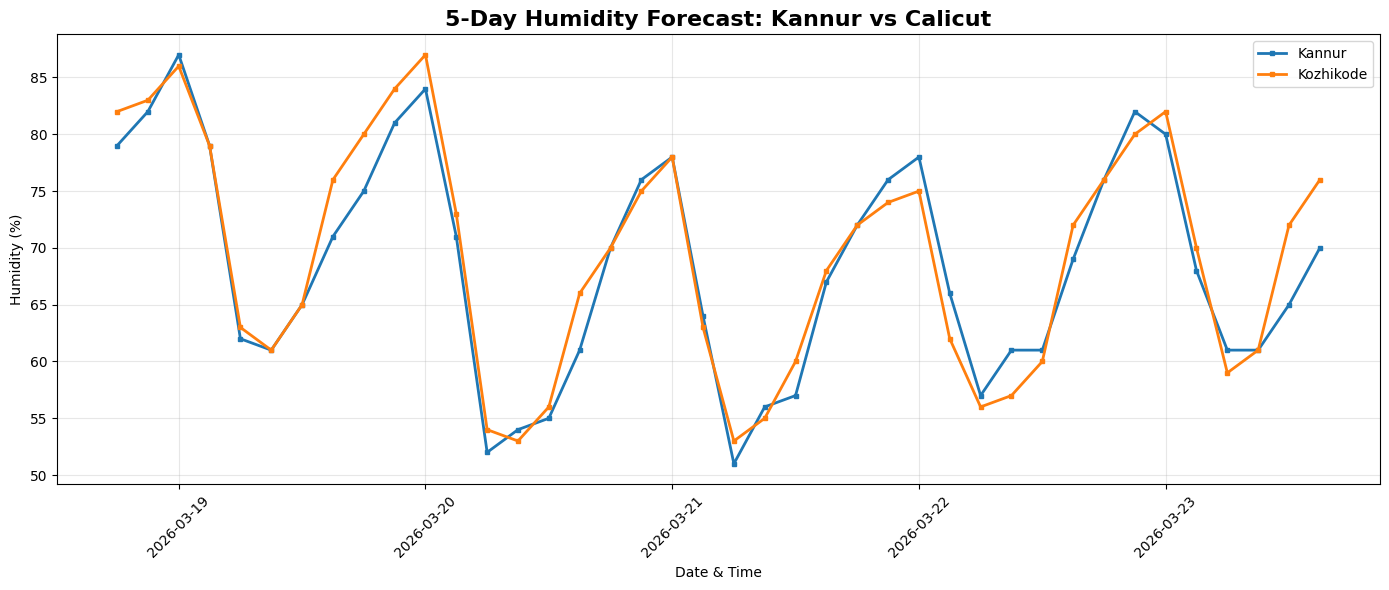

In [24]:
plt.figure(figsize=(14, 6))
for city in ["Kannur", "Kozhikode"]:
    df_city = df_all[df_all["city"] == city]
    plt.plot(df_city["datetime"], df_city["humidity"],
             marker="s", markersize=3, label=city, linewidth=2)

plt.title("5-Day Humidity Forecast: Kannur vs Calicut", fontsize=16, fontweight="bold")
plt.xlabel("Date & Time")
plt.ylabel("Humidity (%)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("humidity_comparison.png", dpi=150)
plt.show()

- Humidity ranges between **52% and 87%** across both cities
- Both cities show a dip around March 20-21
- **Kannur shows higher humidity** than kozhikode on most days

## 3. Weather condition distribution
Breaking down the forecast into clear,cloudy and rainy periods for each city.

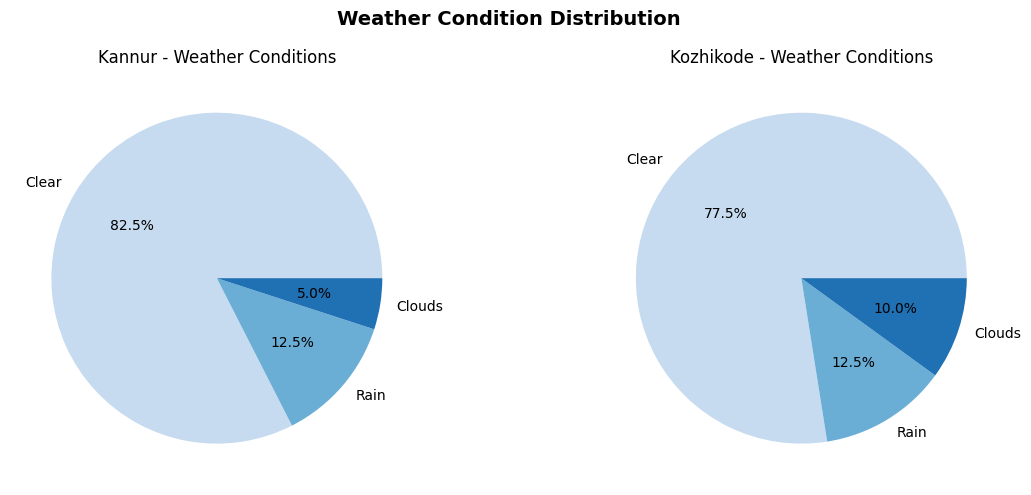

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, city in enumerate(["Kannur", "Kozhikode"]):
    df_city = df_all[df_all["city"] == city]
    counts = df_city["weather"].value_counts()
    axes[i].pie(counts, labels=counts.index, autopct="%1.1f%%",
                colors=sns.color_palette("Blues", len(counts)))
    axes[i].set_title(f"{city} - Weather Conditions")

plt.suptitle("Weather Condition Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("weather_conditions.png", dpi=150)
plt.show()

- **Kannur is 82.5% clear**
- **Kozhikode has slightly more cloud cover** than Kannur
- Both cities have equal rain probability at **12.5%**

In [26]:
for city in ["Kannur", "Kozhikode"]:
    # Preparing data
    df_city = df_all[df_all["city"] == city].sort_values("datetime").copy()
    df_city["time_num"] = np.arange(len(df_city))
    X = df_city["time_num"].values.reshape(-1, 1)
    y = df_city["temperature"].values

    model = LinearRegression().fit(X, y)
    future_steps = np.arange(len(df_city), len(df_city) + 56).reshape(-1, 1)
    predicted = model.predict(future_steps)

    # Generate future dates (3-hour intervals)
    last_date = df_city["datetime"].iloc[-1]
    future_dates = pd.date_range(start=last_date, periods=57, freq="6h")[1:]

    # predictions displayng
    print(f"\n{city} — Predicted Temperatures Beyond 5-Day Forecast")
    for date, temp in zip(future_dates, predicted):
        print(f"{date.strftime('%Y-%m-%d %H:%M')} → {temp:.2f}°C")


Kannur — Predicted Temperatures Beyond 5-Day Forecast
2026-03-23 21:00 → 27.99°C
2026-03-24 03:00 → 28.05°C
2026-03-24 09:00 → 28.10°C
2026-03-24 15:00 → 28.16°C
2026-03-24 21:00 → 28.22°C
2026-03-25 03:00 → 28.27°C
2026-03-25 09:00 → 28.33°C
2026-03-25 15:00 → 28.38°C
2026-03-25 21:00 → 28.44°C
2026-03-26 03:00 → 28.49°C
2026-03-26 09:00 → 28.55°C
2026-03-26 15:00 → 28.61°C
2026-03-26 21:00 → 28.66°C
2026-03-27 03:00 → 28.72°C
2026-03-27 09:00 → 28.77°C
2026-03-27 15:00 → 28.83°C
2026-03-27 21:00 → 28.88°C
2026-03-28 03:00 → 28.94°C
2026-03-28 09:00 → 28.99°C
2026-03-28 15:00 → 29.05°C
2026-03-28 21:00 → 29.11°C
2026-03-29 03:00 → 29.16°C
2026-03-29 09:00 → 29.22°C
2026-03-29 15:00 → 29.27°C
2026-03-29 21:00 → 29.33°C
2026-03-30 03:00 → 29.38°C
2026-03-30 09:00 → 29.44°C
2026-03-30 15:00 → 29.50°C
2026-03-30 21:00 → 29.55°C
2026-03-31 03:00 → 29.61°C
2026-03-31 09:00 → 29.66°C
2026-03-31 15:00 → 29.72°C
2026-03-31 21:00 → 29.77°C
2026-04-01 03:00 → 29.83°C
2026-04-01 09:00 → 29.88°C


## 4. Temperature prediction using Linear Regression
Extending the forecast beyond the 5-day API limit using Machine Learning

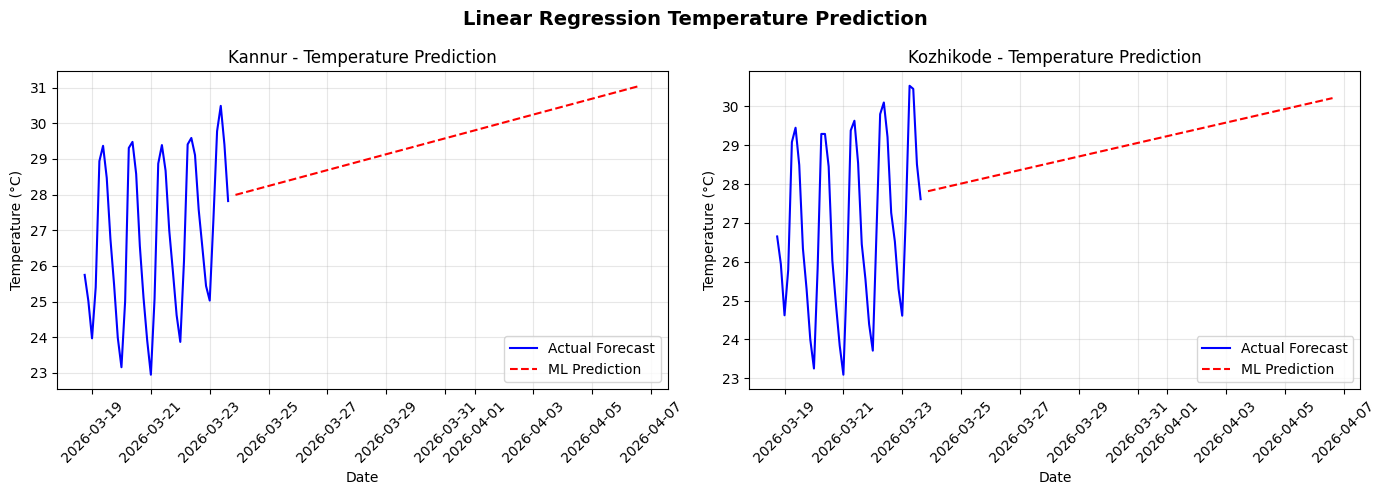

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, city in enumerate(["Kannur", "Kozhikode"]):
    df_city = df_all[df_all["city"] == city].sort_values("datetime").copy()
    df_city["time_num"] = np.arange(len(df_city))

    X, y = df_city["time_num"].values.reshape(-1, 1), df_city["temperature"].values
    model = LinearRegression().fit(X, y)

    future_steps = np.arange(len(df_city), len(df_city) + 56).reshape(-1, 1)
    future_dates = pd.date_range(df_city["datetime"].iloc[-1], periods=57, freq="6h")[1:]

    axes[i].plot(df_city["datetime"], y, label="Actual Forecast", color="blue")
    axes[i].plot(future_dates, model.predict(future_steps),
                 label="ML Prediction", color="red", linestyle="--")
    axes[i].set(title=f"{city} - Temperature Prediction",
                xlabel="Date", ylabel="Temperature (°C)")
    axes[i].legend(); axes[i].grid(alpha=0.3); axes[i].tick_params(axis='x', rotation=45)

plt.suptitle("Linear Regression Temperature Prediction", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("linear_regression_prediction.png", dpi=150)
plt.show()

- **Kannur** temperatures predicted to rise from27°C to around 31°C by April 7
- **Kozhikode** shows a similar rising trendreaching around 30°C by April 7
- Both cities show an **upward temperature trend**

## Note: Linear Regression predicts the average temperature trend,not hourly fluctuations.the smooth prediction line represents the expected mean temperature over time.